In [392]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, auc, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE

# 设置 pandas 显示优化
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.max_colwidth',35)

# 设置显示中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据
df = pd.read_csv("5.Telco-Customer-Churn.csv")
eda_df = df.copy()

# 查看数据基本信息
print(f"数据形状：{df.shape}")
print(f"\n前五行数据：\n{df.head()}")
print(f"\n数据类型与缺失值情况：")
print(df.info())
print(df.describe())

数据形状：(7043, 21)

前五行数据：
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling              PaymentMethod  MonthlyCharges TotalCharges Churn
0  7590-VHVEG  Female              0     Yes         No       1           No  No phone service             DSL             No          Yes               No          No          No              No  Month-to-month              Yes           Electronic check           29.85        29.85    No
1  5575-GNVDE    Male              0      No         No      34          Yes                No             DSL            Yes           No              Yes          No          No              No        One year               No               Mailed check           56.95       1889.5    No
2  3668-QPYBK    Male              0      No         No       2          Yes                No         

### 结果分析

- 数据共有 7043 行，21 列
- 每列代表的含义见表格：
- 没有数据缺失

|字段名|	中文翻译|	说明|
|--|--|--|
|customerID|	客户编号|	唯一用户 ID
|gender|	性别| |	
|SeniorCitizen|	是否老年用户|	1 = 老年人，0 = 非老年|
|Partner|	是否有伴侣|	 |
|Dependents|	是否有家属 / 受抚养人|	子女等家属|
|tenure|	在网时长|	客户使用服务月数|
|PhoneService|	是否开通电话业务| |	
|MultipleLines|	是否多条电话线路|	|
|InternetService|	互联网服务类型|	无 / 光纤 / DSL|
|OnlineSecurity|	在线安全服务|	网络安全增值业务|
|OnlineBackup|	在线备份服务|	|
|DeviceProtection|	设备保护服务| |	
|TechSupport|	技术支持服务|	|
|StreamingTV|	流媒体电视服务|	网络电视|
|StreamingMovies|	流媒体电影服务|	|
|Contract|	合约类型|	月付 / 一年合约 / 两年合约|
|PaperlessBilling|	是否无纸化账单|	|
|PaymentMethod|	支付方式|	|
|MonthlyCharges|	月费用|	每月消费金额|
|TotalCharges|	总费用|	累计消费总额|
|Churn|	是否流失|	1 = 客户销户流失，0 = 留存|

In [393]:
# 统计标签分布
label_cnt = df["Churn"].value_counts()
print("类别分布：")
print(label_cnt)
print(f"留存占比：{label_cnt["No"] / len(df) * 100:.2f}%")
print(f"流失占比：{label_cnt["Yes"] / len(df) * 100:.2f}%")

类别分布：
Churn
No     5174
Yes    1869
Name: count, dtype: int64
留存占比：73.46%
流失占比：26.54%


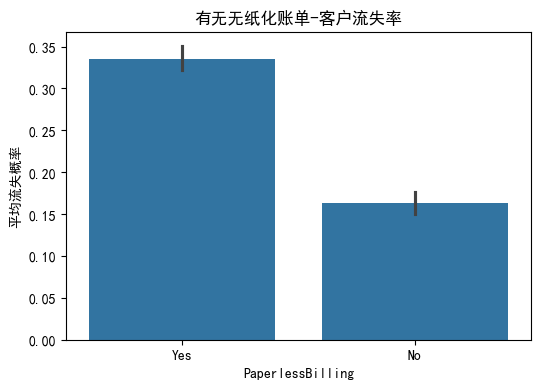

PaperlessBilling
No     0.163301
Yes    0.335651
Name: Churn_num, dtype: float64


In [394]:
""" 看看账单类型的影响 """
''' 增加这一步是因为我主观觉得影响不大，但是又不确定 '''
eda_df["Churn_num"] = eda_df["Churn"].map({"Yes": 1, "No": 0})

plt.figure(figsize=(6,4))
sns.barplot(x="PaperlessBilling", y="Churn_num", data=eda_df)
plt.title("有无无纸化账单-客户流失率")
plt.ylabel("平均流失概率")
plt.show()

# 数值统计
print(eda_df.groupby("PaperlessBilling")["Churn_num"].mean())

In [395]:
# 数据集划分 + 特征工程
""" 凭借个人经验, 初步判断出没用的特征: customerID, 将它丢弃 """
drop_cols = ["customerID"]
df = df.drop(columns=drop_cols)

""" 处理 TotalCharges """
df["TotalCharges"] = df["TotalCharges"].str.strip()
df["TotalCharges"] = df["TotalCharges"].replace("", "0")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

""" 新增几个特征 """
df["AvgMonthlyCharge"] = df["TotalCharges"].astype(float) / (df["tenure"] + 1)                          # 1. 月均消费：总消费 / 在网月数 (+1 防止除以 0)
df["ShortMonthRisk"] = ((df["Contract"] == "Month-to-month") & (df["tenure"] <= 12)).astype(int)        # 2. 短期月付高风险：月付合约 + 在网 ≤12 个月
df["FiberShortRisk"] = ((df["InternetService"] == "Fiber optic") & (df["tenure"] <= 12)).astype(int)    # 3. 光纤短期高风险：光纤业务 + 在网 ≤12 个月

""" 因为大部分特征的类型都是 object, 所以需要进行特征编码 """
df = pd.get_dummies(df, columns=[
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "PaperlessBilling",
    "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"
    ], 
    drop_first=True
)

""" 将 Churn 从 Yes, No ==> 1, 0 """
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

""" 划分数据集 """
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"训练集大小：{X_train.shape}")
print(f"测试集大小：{X_test.shape}")
print(f"\n训练集标签分布：\n{y_train.value_counts()}")
print(f"\n测试集标签分布：\n{y_test.value_counts()}")

""" 标准化数值特征 """
scaler = StandardScaler()
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "AvgMonthlyCharge"]
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

训练集大小：(5634, 33)
测试集大小：(1409, 33)

训练集标签分布：
Churn
0    4139
1    1495
Name: count, dtype: int64

测试集标签分布：
Churn
0    1035
1     374
Name: count, dtype: int64


In [396]:
# 基学习器
estimator = LogisticRegression(class_weight="balanced", max_iter=300)

# 保留 20 个最优特征，自动递归剔除弱特征
rfe = RFE(estimator, n_features_to_select=20, step=1)
X_train = rfe.fit_transform(X_train, y_train)
X_test = rfe.transform(X_test)

# 输出保留/剔除的特征
keep_fea = X.columns[rfe.support_]
drop_fea = X.columns[~rfe.support_]
print("RFE保留特征: \n", list(keep_fea))
print("RFE剔除特征: \n", list(drop_fea))
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

RFE保留特征: 
 ['tenure', 'TotalCharges', 'AvgMonthlyCharge', 'ShortMonthRisk', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'OnlineSecurity_Yes', 'PaperlessBilling_Yes', 'OnlineBackup_No internet service', 'DeviceProtection_No internet service', 'TechSupport_No internet service', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Electronic check']
RFE剔除特征: 
 ['SeniorCitizen', 'MonthlyCharges', 'FiberShortRisk', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Mailed check']
X_train: (5634, 20)
X_test: (1409, 20)


In [397]:
# 统一模型评估函数
def eval_model(model, X_tr, X_te, y_tr, y_te, model_name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    res_dict = {
        "模型名称": model_name,
        "Accuracy": round(accuracy_score(y_te, y_pred), 4),
        "Precision": round(precision_score(y_te, y_pred), 4),
        "Recall": round(recall_score(y_te, y_pred), 4),
        "F1": round(f1_score(y_te, y_pred), 4),
        "AUC": round(roc_auc_score(y_te, y_proba), 4)
    }
    return res_dict, y_proba

In [398]:
# 1. 基础逻辑回归
logicR = LogisticRegression(max_iter=300, random_state=42)
res_lr_base, proba_lr = eval_model(logicR, X_train, X_test, y_train, y_test, "基础逻辑回归")

# 2. 平衡逻辑回归
logicR_balanced = LogisticRegression(max_iter=300, random_state=42, class_weight="balanced")
res_lr_bal, proba_lr_bal = eval_model(logicR_balanced, X_train, X_test, y_train, y_test, "平衡逻辑回归")

# 3. 平衡随机森林
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)
res_rf, proba_rf = eval_model(rf, X_train, X_test, y_train, y_test, "平衡随机森林")

# 4. XGBoost
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)
res_xgb, proba_xgb = eval_model(xgb, X_train, X_test, y_train, y_test, "XGBoost")

# 汇总所有模型指标
all_res = [res_lr_base, res_lr_bal, res_rf, res_xgb]
print("================== 全模型指标汇总对比表 =================")
pd.DataFrame(all_res)

================== 全模型指标汇总对比表 =================


,模型名称,Accuracy,Precision,Recall,F1,AUC
0,基础逻辑回归,0.7991,0.6574,0.5080,0.5732,0.8454
1,平衡逻辑回归,0.7395,0.5060,0.7861,0.6157,0.8453
2,平衡随机森林,0.7566,0.5348,0.6364,0.5812,0.8116
3,XGBoost,0.7601,0.5370,0.6979,0.6070,0.8284


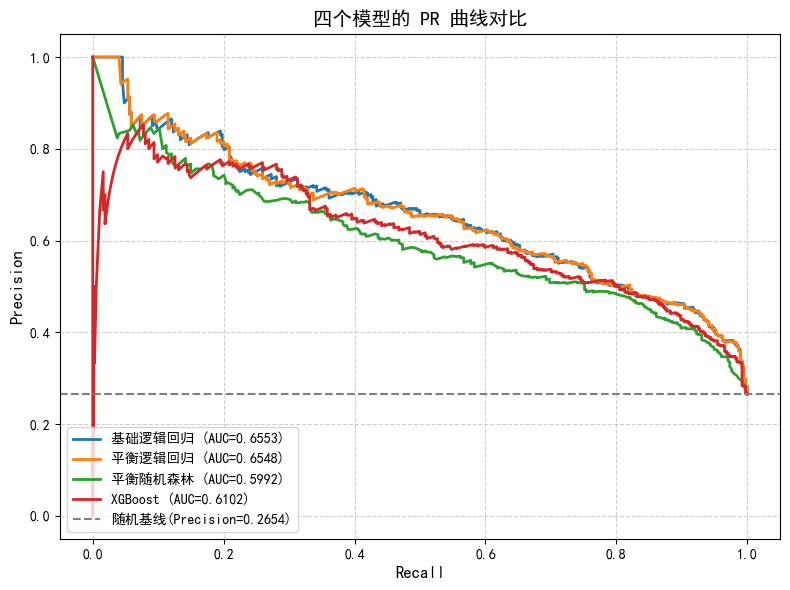

In [399]:
all_precisions = []
all_recalls = []
all_thresholds = []
all_pr_aucs = []

def f(proba):
    precision, recall, thresholds = precision_recall_curve(y_test, proba)
    pr_auc = auc(recall, precision)

    all_precisions.append(precision)
    all_recalls.append(recall)
    all_thresholds.append(thresholds)
    all_pr_aucs.append(pr_auc)

probas = [proba_lr, proba_lr_bal, proba_rf, proba_xgb]
for proba in probas:
    f(proba)

model_names = ["基础逻辑回归", "平衡逻辑回归", "平衡随机森林", "XGBoost"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
plt.figure(figsize=(8, 6))

for i in range(len(model_names)):
    plt.plot(
        all_recalls[i],     # x 轴
        all_precisions[i],  # y 轴
        color = colors[i],
        linewidth=2,
        label=f"{model_names[i]} (AUC={all_pr_aucs[i]:.4f})"
    )

pos_ratio = y_test.mean()
plt.axhline(y=pos_ratio, color="gray", linestyle='--', linewidth=1.5, label=f"随机基线(Precision={pos_ratio:.4f})")

plt.title("四个模型的 PR 曲线对比", fontsize=14)
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.legend(loc="lower left", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [400]:
# 遍历阈值，寻找最优 F1
""" 封装函数 """
def find_best_threshold(proba, t_min=0.05, t_max=0.95, n_steps=50):
    best_f1, best_threshold = 0.0, 0.0

    for t in np.linspace(t_min, t_max, n_steps):
        y_cut = (proba >= t).astype(int)
        f1 = f1_score(y_test, y_cut, zero_division=0)

        if f1 > best_f1:
            best_f1, best_threshold = f1, t

    return best_f1, best_threshold

best_results = []
for proba, model_name in zip(probas, model_names):
    best_f1, best_threshold = find_best_threshold(proba)
    best_results.append({
        "模型名称": model_name,
        "最优分类阈值": round(best_threshold, 4),
        "最优 F1 分数": round(best_f1, 4)
    })

df_best = pd.DataFrame(best_results)
print("各模型【最优F1分类阈值】对比")
df_best

各模型【最优F1分类阈值】对比


,模型名称,最优分类阈值,最优 F1 分数
0,基础逻辑回归,0.3255,0.6301
1,平衡逻辑回归,0.5643,0.6335
2,平衡随机森林,0.3255,0.6030
3,XGBoost,0.3990,0.6188


In [401]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("SMOTE 重采样后训练集分布: ")
print(pd.Series(y_train_smote).value_counts())

""" 逻辑回归 + SMOTE """
logicR_smote = LogisticRegression(
    max_iter=300, 
    random_state=42
)
res_logicR_smote, _ = eval_model(
    logicR_smote,
    X_train_smote,
    X_test,
    y_train_smote,
    y_test,
    "LR + SMOTE 采样"
)

""" XGB + SMOTE """
xgb_smote = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)
res_xgb_smote, _ = eval_model(
    xgb_smote,
    X_train_smote,
    X_test,
    y_train_smote,
    y_test,
    "XGB + SMOTE 采样"
)

all_res.extend([res_logicR_smote, res_xgb_smote])
print("\n================== 新增SMOTE后的完整指标汇总 ==================")
pd.DataFrame(all_res)

SMOTE 重采样后训练集分布: 
Churn
0    4139
1    4139
Name: count, dtype: int64

================== 新增SMOTE后的完整指标汇总 ==================


,模型名称,Accuracy,Precision,Recall,F1,AUC
0,基础逻辑回归,0.7991,0.6574,0.5080,0.5732,0.8454
1,平衡逻辑回归,0.7395,0.5060,0.7861,0.6157,0.8453
2,平衡随机森林,0.7566,0.5348,0.6364,0.5812,0.8116
3,XGBoost,0.7601,0.5370,0.6979,0.6070,0.8284
4,LR + SMOTE 采样,0.7367,0.5026,0.7888,0.6139,0.8446
5,XGB + SMOTE 采样,0.7708,0.5627,0.6123,0.5864,0.8135


In [402]:
# 网格搜索
param_grid_logicR = {
    "C": [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 20, 50, 100] # C 是正则化强度的倒数，C 越大正则化越弱。
}

grid = GridSearchCV(
    estimator=LogisticRegression(class_weight="balanced", max_iter=500, random_state=42),
    param_grid=param_grid_logicR,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(f"平衡逻辑回归网格搜索最优参数: {grid.best_params_}")
print(f"5 折交叉验证最优 F1: {grid.best_score_:.4f}")

best_lr = grid.best_estimator_
res_best_lr, best_proba = eval_model(best_lr, X_train, X_test, y_train, y_test, "网格调优平衡逻辑回归")
pd.DataFrame([res_best_lr])

平衡逻辑回归网格搜索最优参数: {'C': 20}
5 折交叉验证最优 F1: 0.6305


,模型名称,Accuracy,Precision,Recall,F1,AUC
0,网格调优平衡逻辑回归,0.7381,0.5043,0.7834,0.6136,0.8452


In [403]:
risk_df = pd.DataFrame({
    "流失概率": best_proba,     # 模型预测的每个客户的流失概率
    "真实标签": y_test.values   # 测试集的真实流失标签
})

# 自定义三层风险划分
def risk_tag(p):
    if p >= 0.7:
        return "高风险"
    elif p >= 0.3:
        return "中风险"
    else:
        return "低风险"

risk_df["风险等级"] = risk_df["流失概率"].apply(risk_tag)

# 分层统计数量 & 真实流失率
stat = risk_df.groupby("风险等级").agg(
    客户数量=("流失概率", "count"),
    实际流失占比=("真实标签", "mean")
).round(4)

risk_order = ["高风险", "中风险", "低风险"]
stat = stat.reindex(risk_order)

print("客户风险分层统计：\n", stat)

客户风险分层统计：
       客户数量  实际流失占比
风险等级              
高风险    347  0.6254
中风险    465  0.2839
低风险    597  0.0419


In [404]:
def predict_churn(raw_customer_info):
    """
    电信客户流失线上推理函数
    参数：
        raw_customer_info: dict, 原始客户字段
    返回：
        churn_prob: float 客户流失概率(0~1)
        risk_level: str 流失风险等级
    """

    # 1. 转为单行 DataFrame
    full_cols = list(X.columns)
    input_df = pd.DataFrame([raw_customer_info], columns=full_cols)

    # 2. 统一处理数值字段标准化
    num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "AvgMonthlyCharge"]
    input_df[num_cols] = scaler.transform(input_df[num_cols])

    # 3. RFE 特征筛选，转为保留的 20 维特征
    input_rfe = rfe.transform(input_df)

    # 4. 使用网格调优平衡逻辑回归预测流失概率
    churn_prob = (best_lr.predict_proba(input_rfe)[0, 1])
    churn_prob = round(churn_prob, 4)

    # 5. 根据概率划分风险
    risk_level = risk_tag(churn_prob)

    return churn_prob, risk_level

In [405]:
# 模拟一条高流失风险客户原始数据
test_customer = {
    "tenure": 5,
    "MonthlyCharges": 74.5,
    "TotalCharges": 372.5,
    "AvgMonthlyCharge": 74.5,
    "ShortMonthRisk": 1,
    "FiberShortRisk": 1,
    "gender_Male": 1,
    "SeniorCitizen": 0,
    "Partner_Yes": 0,
    "Dependents_Yes": 0,
    "PhoneService_Yes": 1,
    "MultipleLines_No phone service": 0,
    "MultipleLines_Yes": 0,
    "InternetService_Fiber optic": 1,
    "InternetService_No": 0,
    "OnlineSecurity_Yes": 0,
    "OnlineSecurity_No internet service": 0,
    "OnlineBackup_Yes": 0,
    "OnlineBackup_No internet service": 1,
    "DeviceProtection_Yes": 0,
    "DeviceProtection_No internet service": 1,
    "TechSupport_Yes": 0,
    "TechSupport_No internet service": 1,
    "StreamingTV_Yes": 1,
    "StreamingTV_No internet service": 0,
    "StreamingMovies_Yes": 1,
    "StreamingMovies_No internet service": 0,
    "Contract_One year": 0,
    "Contract_Two year": 0,
    "PaymentMethod_Electronic check": 1,
    "PaymentMethod_Credit card (automatic)": 0,
    "PaymentMethod_Mailed check": 0,
    "PaperlessBilling_Yes": 1
}

# 推理调用
prob, risk = predict_churn(test_customer)
print(f"客户流失概率：{prob*100:.2f}% ({risk})")

客户流失概率：81.76% (高风险)
